### Phase 4: Portfolio Construction and Backtesting

In [1]:
# ====================================================
# STEP 0: Setup Path
# ====================================================

import pandas as pd
import numpy as np
from pathlib import Path

# Go one level up (same as Phase 3 logic)
PROJECT_ROOT = Path().resolve().parent

INPUT_DIR = PROJECT_ROOT / "data" / "portfolio_construction_inputs"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_DIR:", INPUT_DIR.resolve())

PROJECT_ROOT: C:\Users\jayan\Study Materials\ml_alpha_portfolio\ml-alpha-portfolio-model
INPUT_DIR: C:\Users\jayan\Study Materials\ml_alpha_portfolio\ml-alpha-portfolio-model\data\portfolio_construction_inputs


In [2]:
# ====================================================
# STEP 1: Data preparation
# ====================================================

# Load predictions
pred_df = pd.read_csv(INPUT_DIR / "predictions.csv", parse_dates=["date"])

# Load panel
panel = pd.read_csv(INPUT_DIR / "panel_phase4.csv", parse_dates=["date"])

print("Pred shape:", pred_df.shape)
print("Panel shape:", panel.shape)

Pred shape: (120293, 4)
Panel shape: (131642, 4)


In [3]:
df = pred_df.merge(
    panel,
    on=["date", "ticker"],
    how="left"
)

# Safety check
df = df.dropna(subset=["prediction", "close"])

print("Merged df shape:", df.shape)

df = df.sort_values(["ticker", "date"])
df["ret_1d"] = df.groupby("ticker")["close"].pct_change()

Merged df shape: (120293, 6)


In [4]:
print(df.head())

        date ticker  prediction  future_return_21d    close       sector  \
0 2020-12-02    ABB    0.012671           0.035186  1190.80  Industrials   
1 2020-12-03    ABB    0.018657           0.077560  1172.00  Industrials   
2 2020-12-04    ABB    0.019802           0.120534  1154.45  Industrials   
3 2020-12-07    ABB    0.007570           0.123555  1154.95  Industrials   
4 2020-12-08    ABB    0.002236           0.128031  1154.80  Industrials   

     ret_1d  
0       NaN  
1 -0.015788  
2 -0.014974  
3  0.000433  
4 -0.000130  


In [5]:
print(df.isna().sum())

date                  0
ticker                0
prediction            0
future_return_21d     0
close                 0
sector                0
ret_1d               95
dtype: int64


In [6]:
df = df.dropna(subset='ret_1d')

In [7]:
print("Unique dates:", df["date"].nunique())

Unique dates: 1280


In [8]:
print("Unique tickers:", df["ticker"].nunique())

Unique tickers: 95


In [9]:
# ============================================================
# STEP 2: REBALANCING DATES (21-Day Frequency)
# ============================================================

df = df.sort_values("date")

all_dates = sorted(df["date"].dt.normalize().unique())

REBALANCE_FREQ = 21
rebalance_dates = all_dates[::REBALANCE_FREQ]

print("Total rebalance points:", len(rebalance_dates))
print("First 5 rebalance dates:", rebalance_dates[:5])

Total rebalance points: 61
First 5 rebalance dates: [numpy.datetime64('2020-12-03T00:00:00.000000000'), numpy.datetime64('2021-01-04T00:00:00.000000000'), numpy.datetime64('2021-02-03T00:00:00.000000000'), numpy.datetime64('2021-03-04T00:00:00.000000000'), numpy.datetime64('2021-04-07T00:00:00.000000000')]


In [10]:
# Convert to pandas Timestamp (clean format)
rebalance_dates = pd.to_datetime(rebalance_dates)

In [11]:
rebalance_dates

DatetimeIndex(['2020-12-03', '2021-01-04', '2021-02-03', '2021-03-04',
               '2021-04-07', '2021-05-10', '2021-06-09', '2021-07-08',
               '2021-08-09', '2021-09-08', '2021-10-08', '2021-11-10',
               '2021-12-10', '2022-01-10', '2022-02-09', '2022-03-11',
               '2022-04-12', '2022-05-16', '2022-06-14', '2022-07-13',
               '2022-08-12', '2022-09-14', '2022-10-14', '2022-11-16',
               '2022-12-15', '2023-01-13', '2023-02-14', '2023-03-16',
               '2023-04-20', '2023-05-22', '2023-06-20', '2023-07-20',
               '2023-08-21', '2023-09-20', '2023-10-20', '2023-11-21',
               '2023-12-21', '2024-01-20', '2024-02-21', '2024-03-21',
               '2024-04-25', '2024-05-27', '2024-06-26', '2024-07-26',
               '2024-08-27', '2024-09-25', '2024-10-25', '2024-11-27',
               '2024-12-27', '2025-01-27', '2025-02-24', '2025-03-27',
               '2025-05-02', '2025-06-02', '2025-07-01', '2025-07-30',
      

In [12]:
# ============================================================
# STEP 3: PORTFOLIO PARAMETERS
# ============================================================

TOP_N = 10

WEIGHTING = "equal"   # options: "equal" / "prediction"

MAX_WEIGHT = 0.10     # max 10% per stock
TRANSACTION_COST = 0.001   # 0.1%

print("TOP_N:", TOP_N)
print("Weighting:", WEIGHTING)

TOP_N: 10
Weighting: equal


In [13]:
# ============================================================
# STEP 4: PORTFOLIO CONSTRUCTION
# ============================================================

portfolio_returns = []
current_weights = {}

for i in range(len(rebalance_dates)):

    rebalance_date = rebalance_dates[i]

    temp = df[df["date"] == rebalance_date].copy()
    temp = temp.dropna(subset=["prediction"])

    # Rank stocks
    temp = temp.sort_values("prediction", ascending=False)

    # Select Top N
    selected = temp.head(TOP_N).copy()

    # =========================
    # WEIGHTING SCHEME
    # =========================
    if WEIGHTING == "equal":
        selected["weight"] = 1.0 / TOP_N

    elif WEIGHTING == "prediction":
        selected["weight"] = selected["prediction"].clip(lower=0)
        selected["weight"] = selected["weight"] / selected["weight"].sum()

    # =========================
    # APPLY MAX WEIGHT
    # =========================
    selected["weight"] = np.minimum(selected["weight"], MAX_WEIGHT)
    selected["weight"] = selected["weight"] / selected["weight"].sum()

    new_weights = dict(zip(selected["ticker"], selected["weight"]))

    # =========================
    # TURNOVER CALCULATION
    # =========================
    turnover = 0

    for ticker in set(current_weights.keys()).union(new_weights.keys()):
        old_w = current_weights.get(ticker, 0)
        new_w = new_weights.get(ticker, 0)
        turnover += abs(new_w - old_w)

    cost = turnover * TRANSACTION_COST

    # =========================
    # HOLDING PERIOD RETURNS
    # =========================
    if i < len(rebalance_dates) - 1:
        next_date = rebalance_dates[i + 1]
        period_df = df[(df["date"] > rebalance_date) & (df["date"] <= next_date)].copy()
    else:
        period_df = df[df["date"] > rebalance_date].copy()

    for d in sorted(period_df["date"].unique()):

        daily = period_df[period_df["date"] == d]

        ret = 0

        for ticker, w in new_weights.items():
            r = daily.loc[daily["ticker"] == ticker, "ret_1d"]
            if len(r) > 0:
                ret += w * r.values[0]

        # Deduct transaction cost only on rebalance day
        if d == period_df["date"].min():
            ret -= cost

        portfolio_returns.append({
            "date": d,
            "return": ret
        })

    current_weights = new_weights.copy()

In [14]:
# ============================================================
# STEP 5: PORTFOLIO DATAFRAME
# ============================================================

portfolio_df = pd.DataFrame(portfolio_returns)

portfolio_df = portfolio_df.sort_values("date").reset_index(drop=True)

print(portfolio_df.head())

        date    return
0 2020-12-04  0.009822
1 2020-12-07  0.012101
2 2020-12-08  0.020073
3 2020-12-09 -0.007143
4 2020-12-10 -0.004903


In [15]:
# ============================================================
# STEP 6: CUMULATIVE RETURNS
# ============================================================

portfolio_df["cum_return"] = (1 + portfolio_df["return"]).cumprod()

print(portfolio_df.describe())

            return   cum_return
count  1279.000000  1279.000000
mean      0.000965     2.264106
std       0.013216     0.899929
min      -0.098148     0.995663
25%      -0.005393     1.474487
50%       0.001654     1.744305
75%       0.008238     3.298645
max       0.054448     3.670865


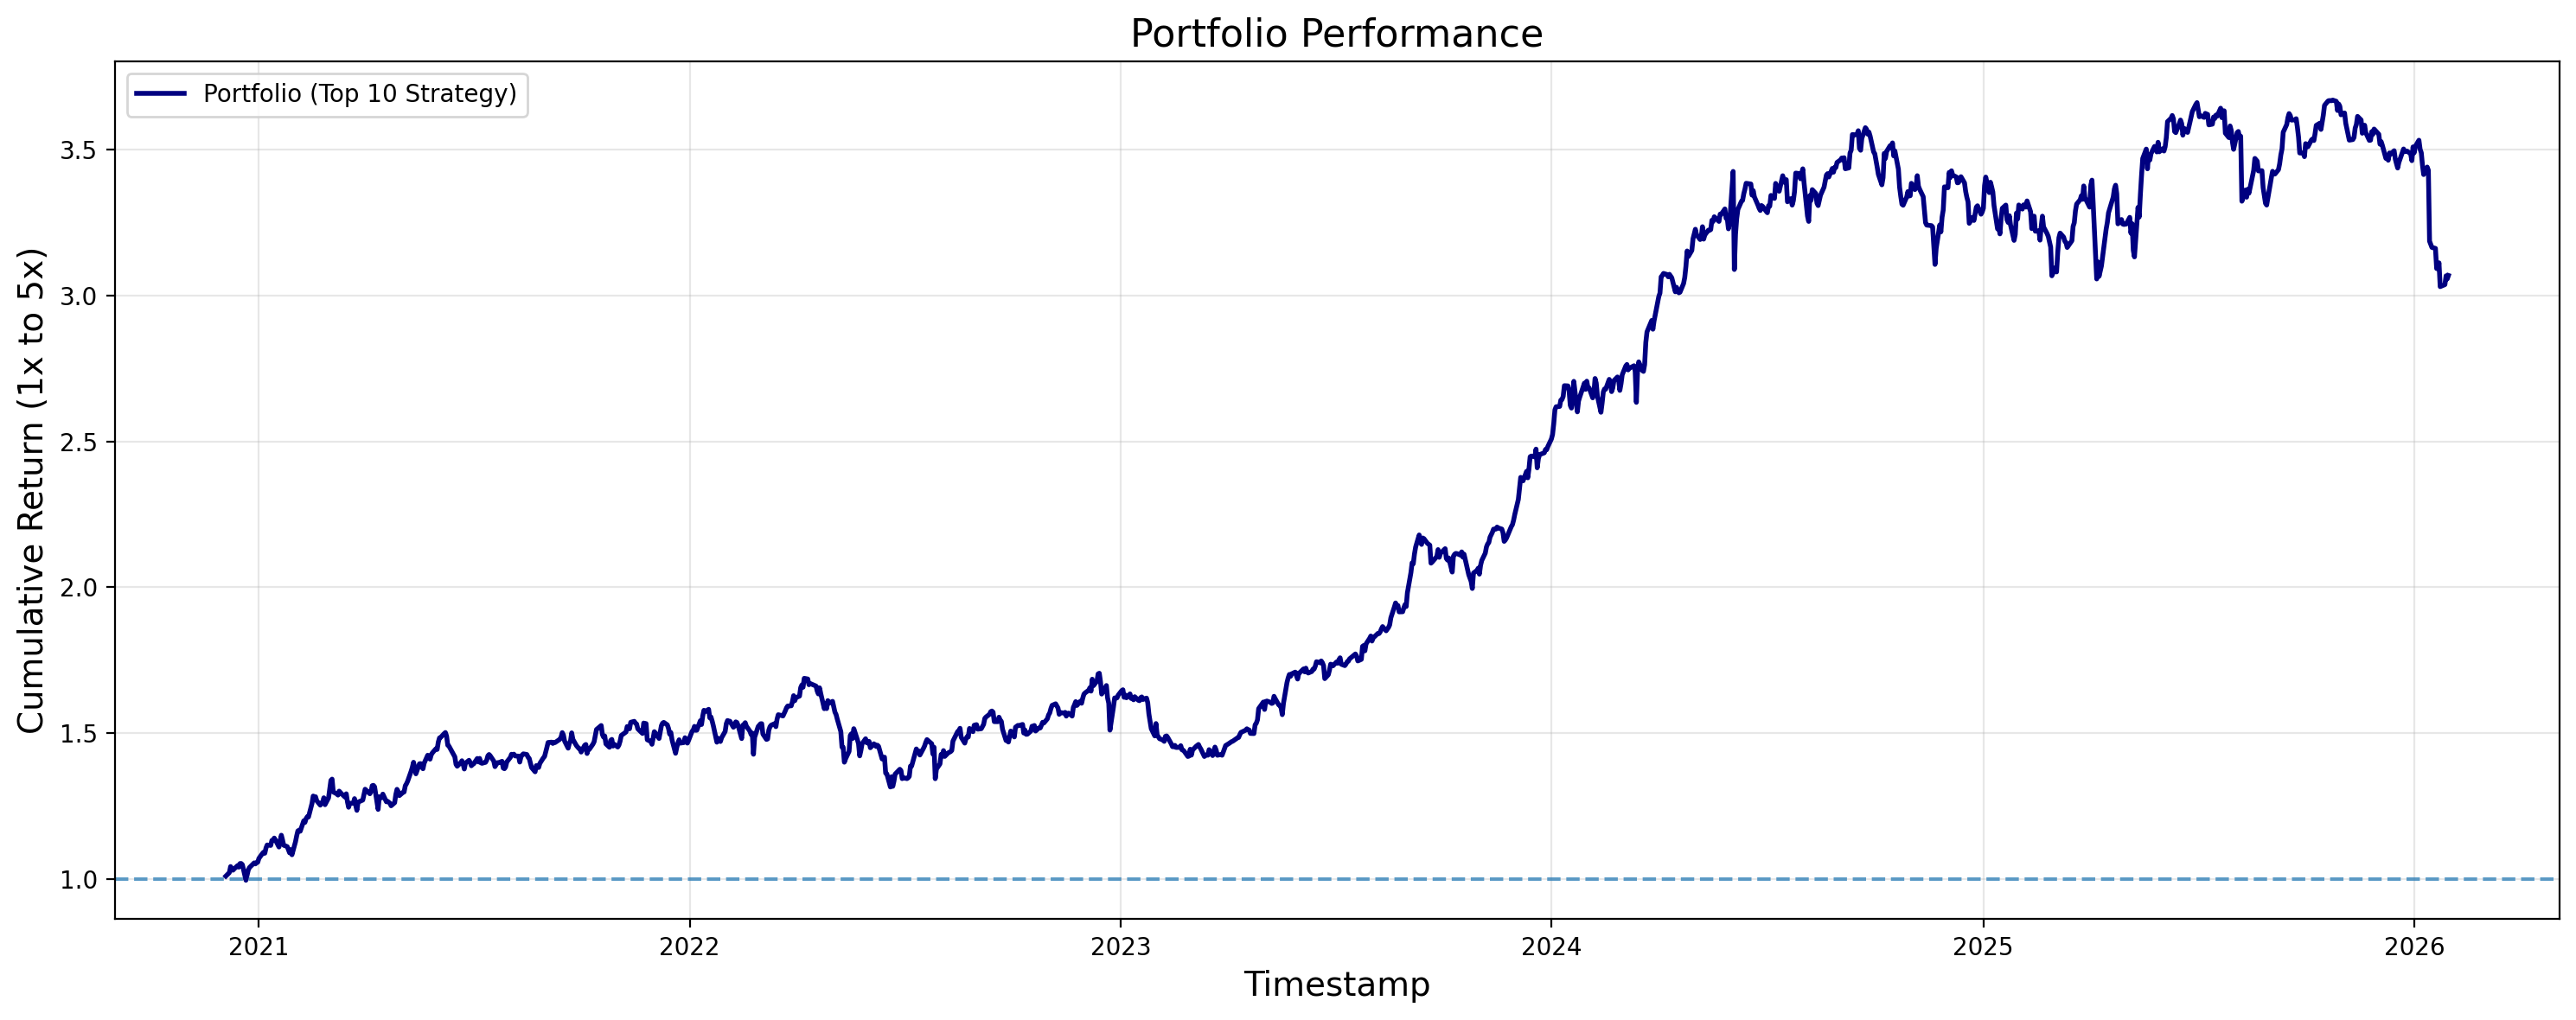

In [16]:
# ============================================================
# STEP 7: RETURN TRENDS AND COMPARISON WITH NIFTY100
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6), dpi=200)

plt.plot(
    portfolio_df["date"],
    portfolio_df["cum_return"],
    label="Portfolio (Top 10 Strategy)",
    linewidth=2,
    color='navy'
)

plt.axhline(1, linestyle="--", alpha=0.7)

plt.title("Portfolio Performance", fontsize=16)
plt.xlabel("Timestamp", fontsize=14)
plt.ylabel("Cumulative Return (1x to 5x)", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

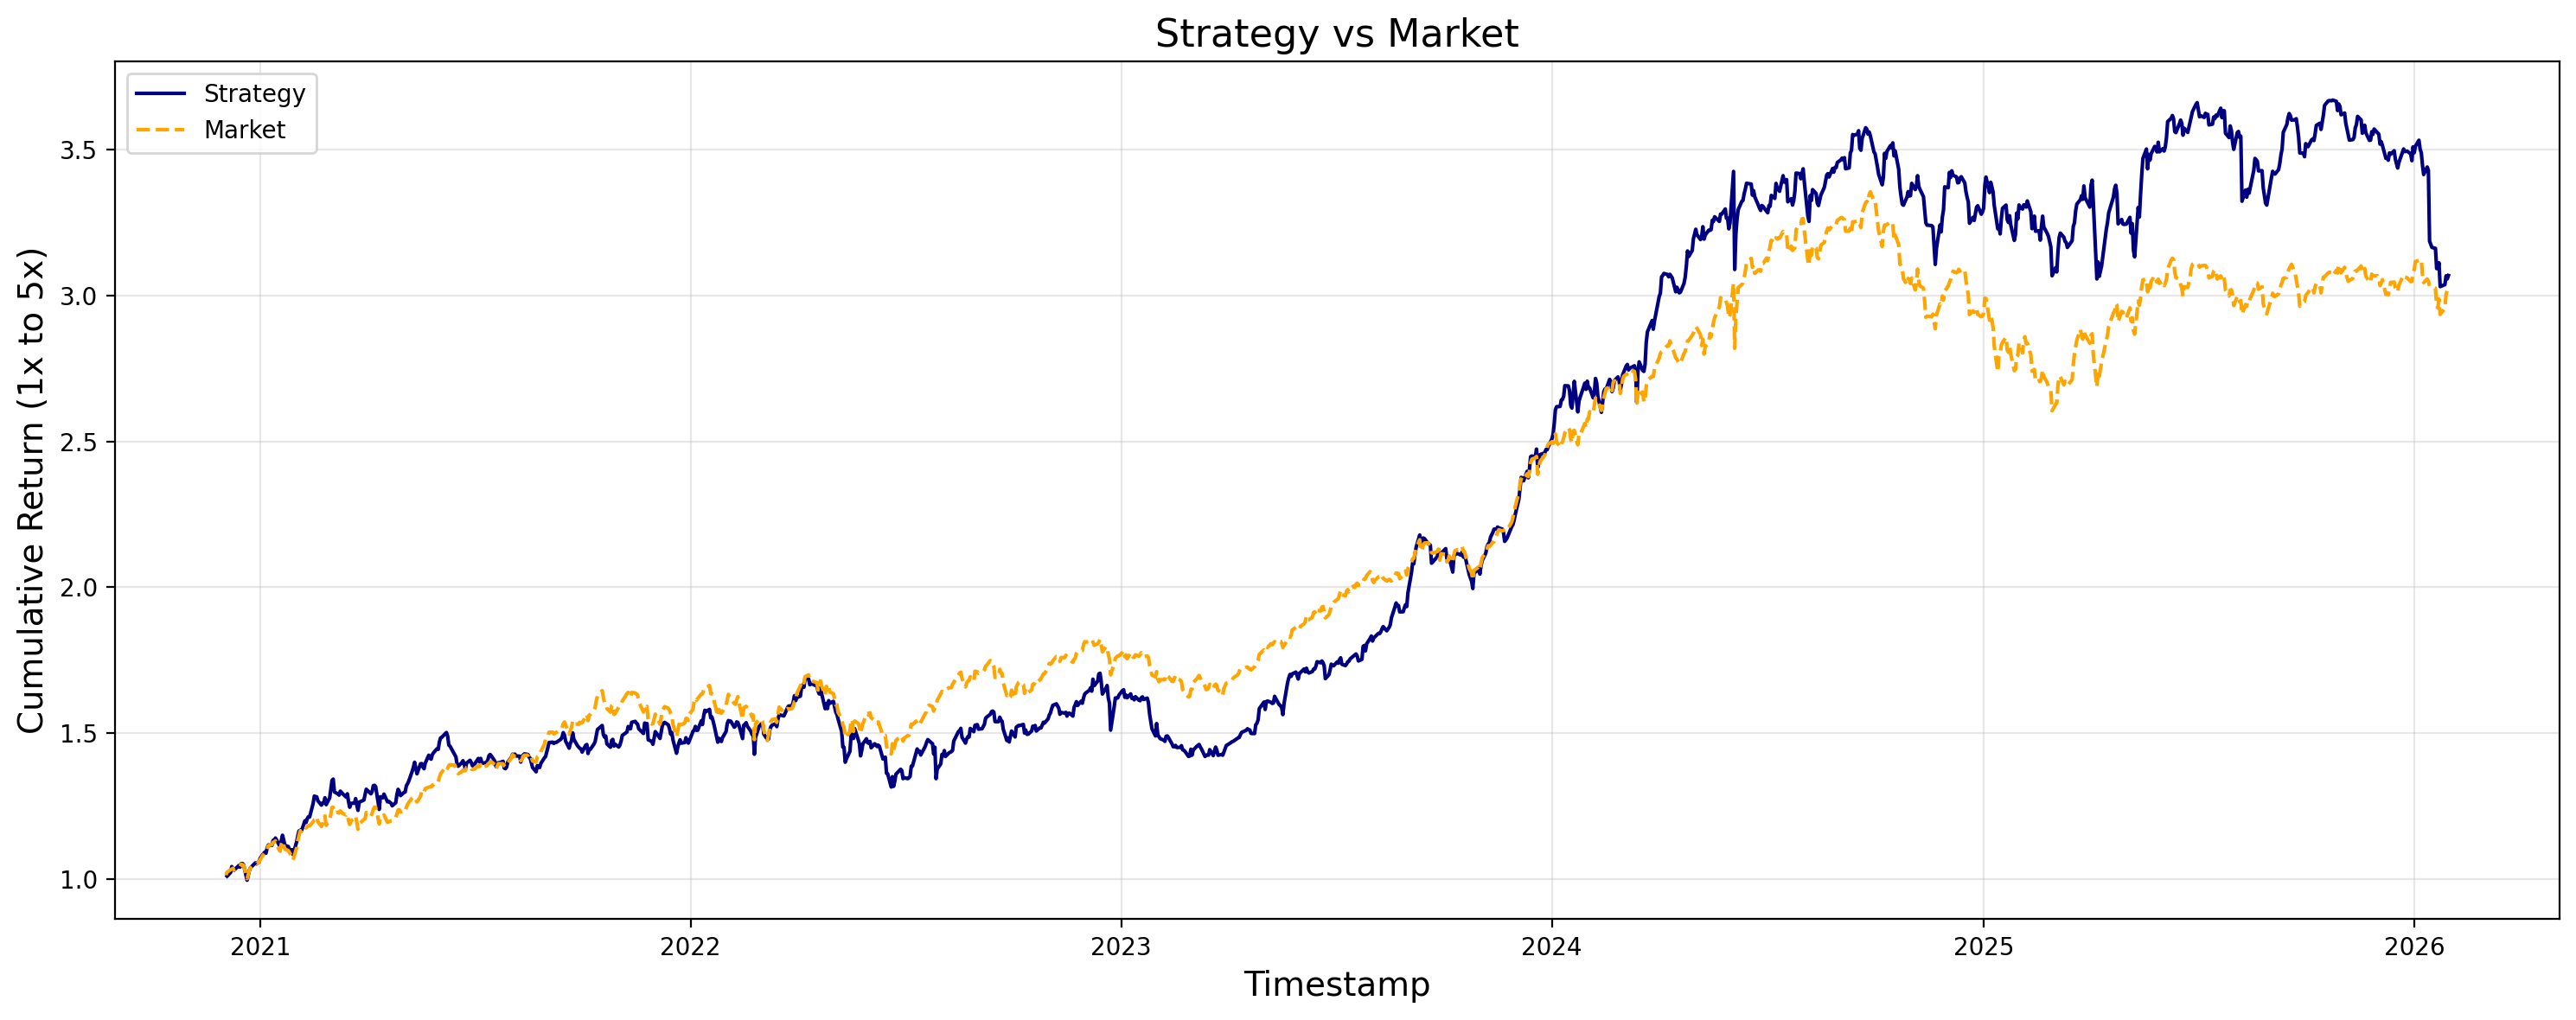

In [17]:
# Equi-weighted market return
market_ret = df.groupby("date")["ret_1d"].mean().reset_index()
market_ret["cum_market"] = (1 + market_ret["ret_1d"]).cumprod()

plt.figure(figsize=(15, 6), dpi=200)

plt.plot(portfolio_df["date"], portfolio_df["cum_return"], label="Strategy", color='navy')
plt.plot(market_ret["date"], market_ret["cum_market"], label="Market", color='orange', linestyle="--")

plt.legend()
plt.title("Strategy vs Market", fontsize=16)
plt.xlabel("Timestamp", fontsize=14)
plt.ylabel("Cumulative Return (1x to 5x)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# STEP 9: Performance Metrics
# ============================================================

In [19]:
# -------------------------------------------
# ROLLING XIRR AND TREND SINCE 2021
# -------------------------------------------

In [20]:
from scipy.optimize import newton

# -----------------------------------------
# XIRR FUNCTION
# -----------------------------------------
def xirr(dates, cashflows, guess=0.1):
    dates = pd.to_datetime(dates)
    
    def xnpv(rate):
        return sum([
            cf / (1 + rate) ** ((d - dates[0]).days / 365)
            for cf, d in zip(cashflows, dates)
        ])
    
    return newton(xnpv, guess)

# -----------------------------------------
# CREATE CASH FLOWS
# -----------------------------------------

# Assume starting capital = -1 (investment)
cashflows = [-1]

# Final value
final_value = portfolio_df["cum_return"].iloc[-1]

# Intermediate flows = 0
cashflows += [0] * (len(portfolio_df) - 2)

# Last inflow
cashflows.append(final_value)

dates = portfolio_df["date"].tolist()

# -----------------------------------------
# COMPUTE XIRR
# -----------------------------------------
xirr_value = xirr(dates, cashflows)

print(f"XIRR or CAGR (Annualized Return): {xirr_value:.2%}")

XIRR or CAGR (Annualized Return): 24.28%


In [21]:
rolling_xirr = []

for i in range(30, len(portfolio_df)):  # start after some data
    
    temp = portfolio_df.iloc[:i]

    dates = temp["date"].tolist()
    
    cashflows = [-1] + [0] * (len(temp) - 2) + [temp["cum_return"].iloc[-1]]

    try:
        val = xirr(dates, cashflows)
    except:
        val = np.nan

    rolling_xirr.append(val)

# Align with dates
xirr_df = pd.DataFrame({
    "date": portfolio_df["date"].iloc[30:].values,
    "xirr": rolling_xirr
})

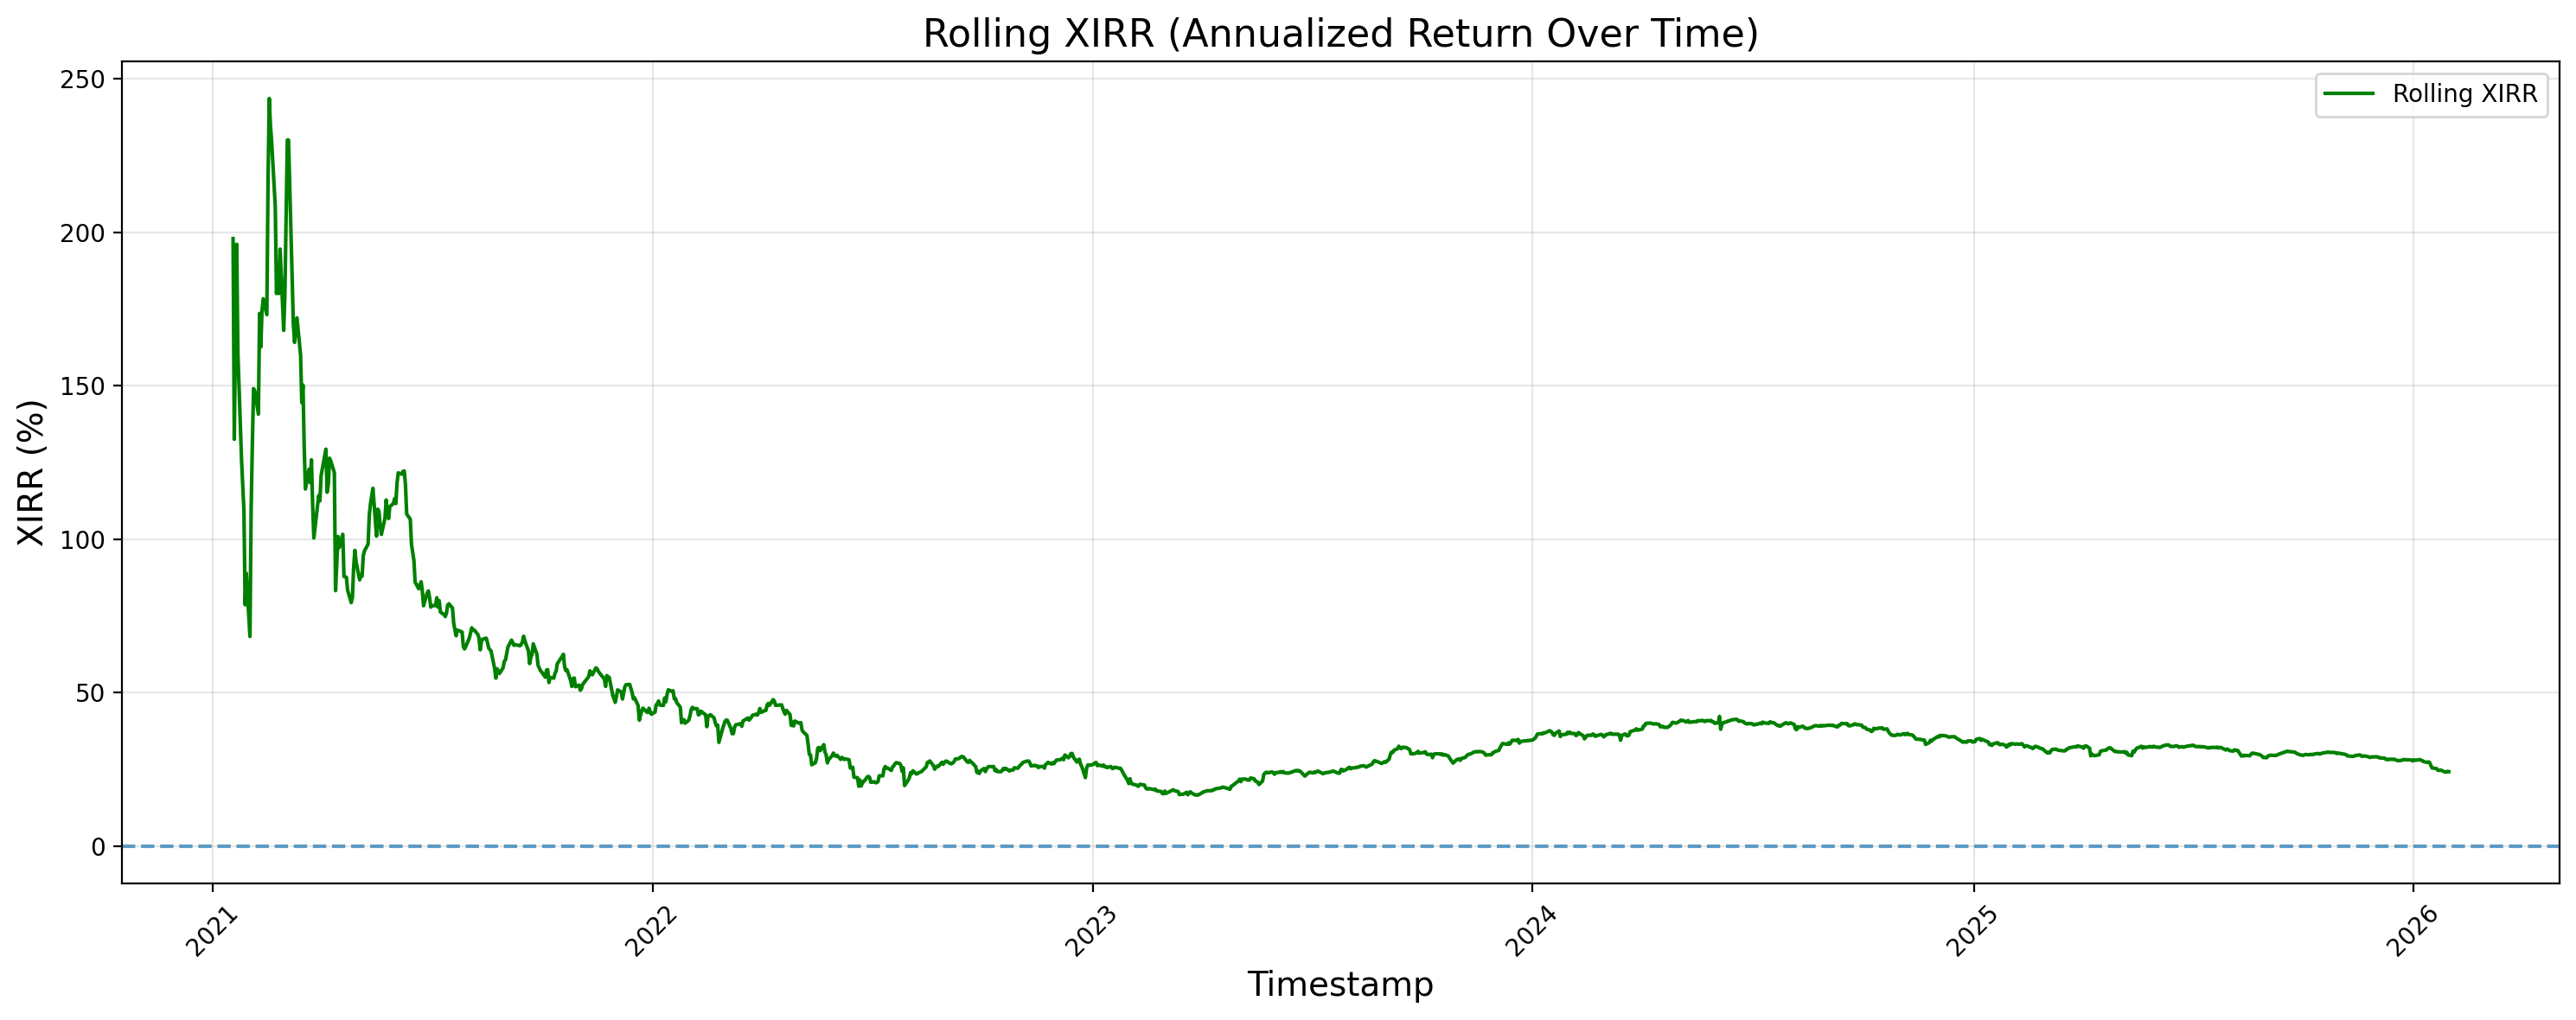

In [38]:
plt.figure(figsize=(15, 6), dpi=200)

plt.plot(xirr_df["date"], xirr_df["xirr"]*100, color='green', label="Rolling XIRR")

plt.axhline(0, linestyle="--", alpha=0.7)

plt.title("Rolling XIRR (Annualized Return Over Time)", fontsize=16)
plt.xlabel("Timestamp", fontsize=14)
plt.ylabel("XIRR (%)", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** 50 means 50% annualized return

The root cause behind erratic trend in the beginning is annualization over very few days, which later gets streamlined.

In [23]:
# -----------------------------------------
# BASIC SETTINGS
# -----------------------------------------
TRADING_DAYS = 252

returns = portfolio_df["return"].dropna()

In [24]:
# -----------------------------------------
# CAGR
# -----------------------------------------
total_days = (portfolio_df["date"].iloc[-1] - portfolio_df["date"].iloc[0]).days
years = total_days / 365

final_value = portfolio_df["cum_return"].iloc[-1]

cagr = final_value ** (1 / years) - 1

In [25]:
# -----------------------------------------
# PORTFOLIO VOLATILITY (Annualized)
# -----------------------------------------
volatility = returns.std() * np.sqrt(TRADING_DAYS)


In [26]:
# -----------------------------------------
# SHARPE RATIO
# -----------------------------------------
sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS)


In [27]:
# -----------------------------------------
# SORTINO RATIO
# -----------------------------------------
downside = returns[returns < 0]
downside_std = downside.std()

sortino = (returns.mean() / downside_std) * np.sqrt(TRADING_DAYS)


In [28]:
# -----------------------------------------
# MAX DRAWDOWN
# -----------------------------------------
cum = portfolio_df["cum_return"]
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

max_dd = drawdown.min()


In [29]:
print(f"CAGR: {cagr:.2%}")
print(f"Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Sortino Ratio: {sortino:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")

CAGR: 24.28%
Volatility: 20.98%
Sharpe Ratio: 1.16
Sortino Ratio: 1.41
Max Drawdown: -22.07%


In [30]:
# -----------------------------------------
# ROLLING SHARPE
# -----------------------------------------

window = 63  # ~3 months

rolling_sharpe = (
    returns.rolling(window).mean() /
    returns.rolling(window).std()
) * np.sqrt(TRADING_DAYS)

portfolio_df["rolling_sharpe"] = rolling_sharpe


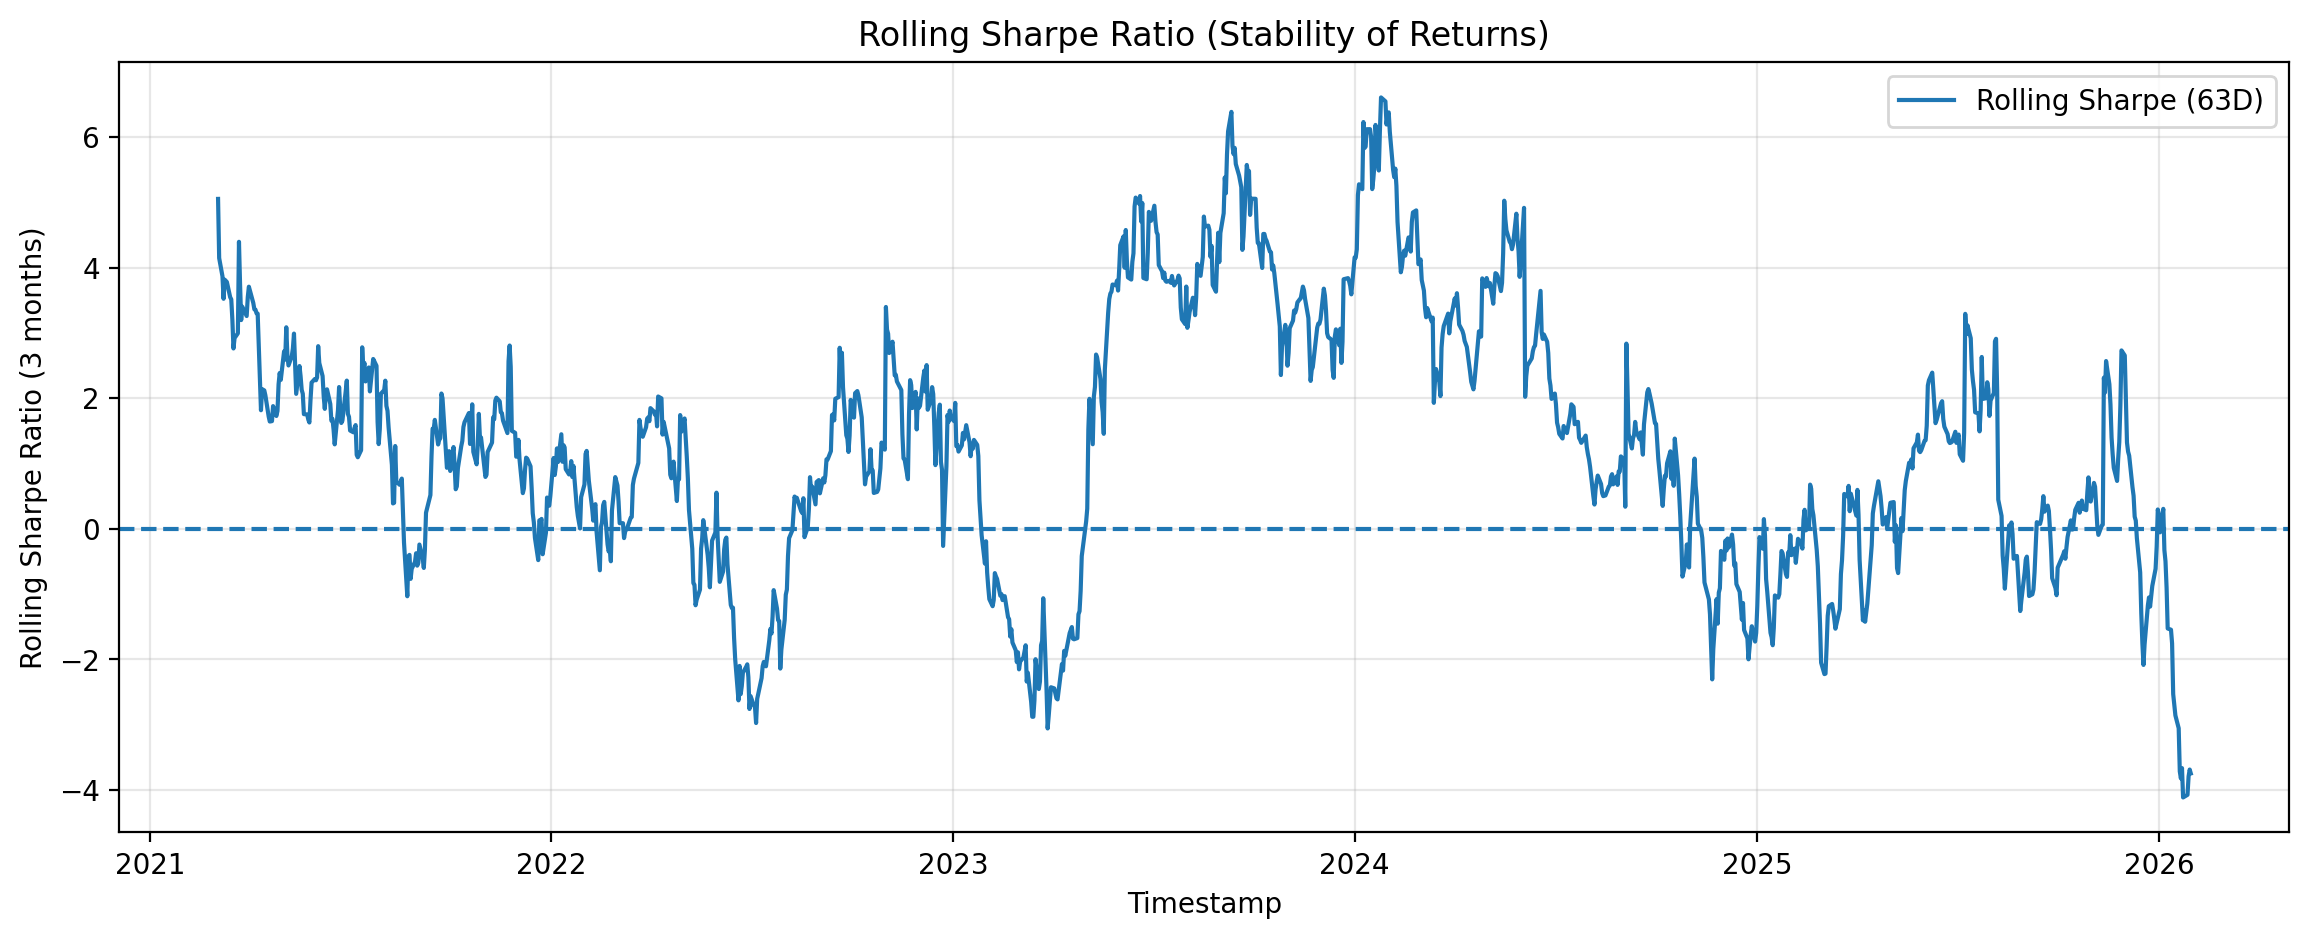

In [31]:
plt.figure(figsize=(14,5), dpi=200)

plt.plot(portfolio_df["date"], portfolio_df["rolling_sharpe"], label="Rolling Sharpe (63D)")
plt.axhline(0, linestyle="--")

plt.title("Rolling Sharpe Ratio (Stability of Returns)")
plt.xlabel("Timestamp")
plt.ylabel("Rolling Sharpe Ratio (3 months)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

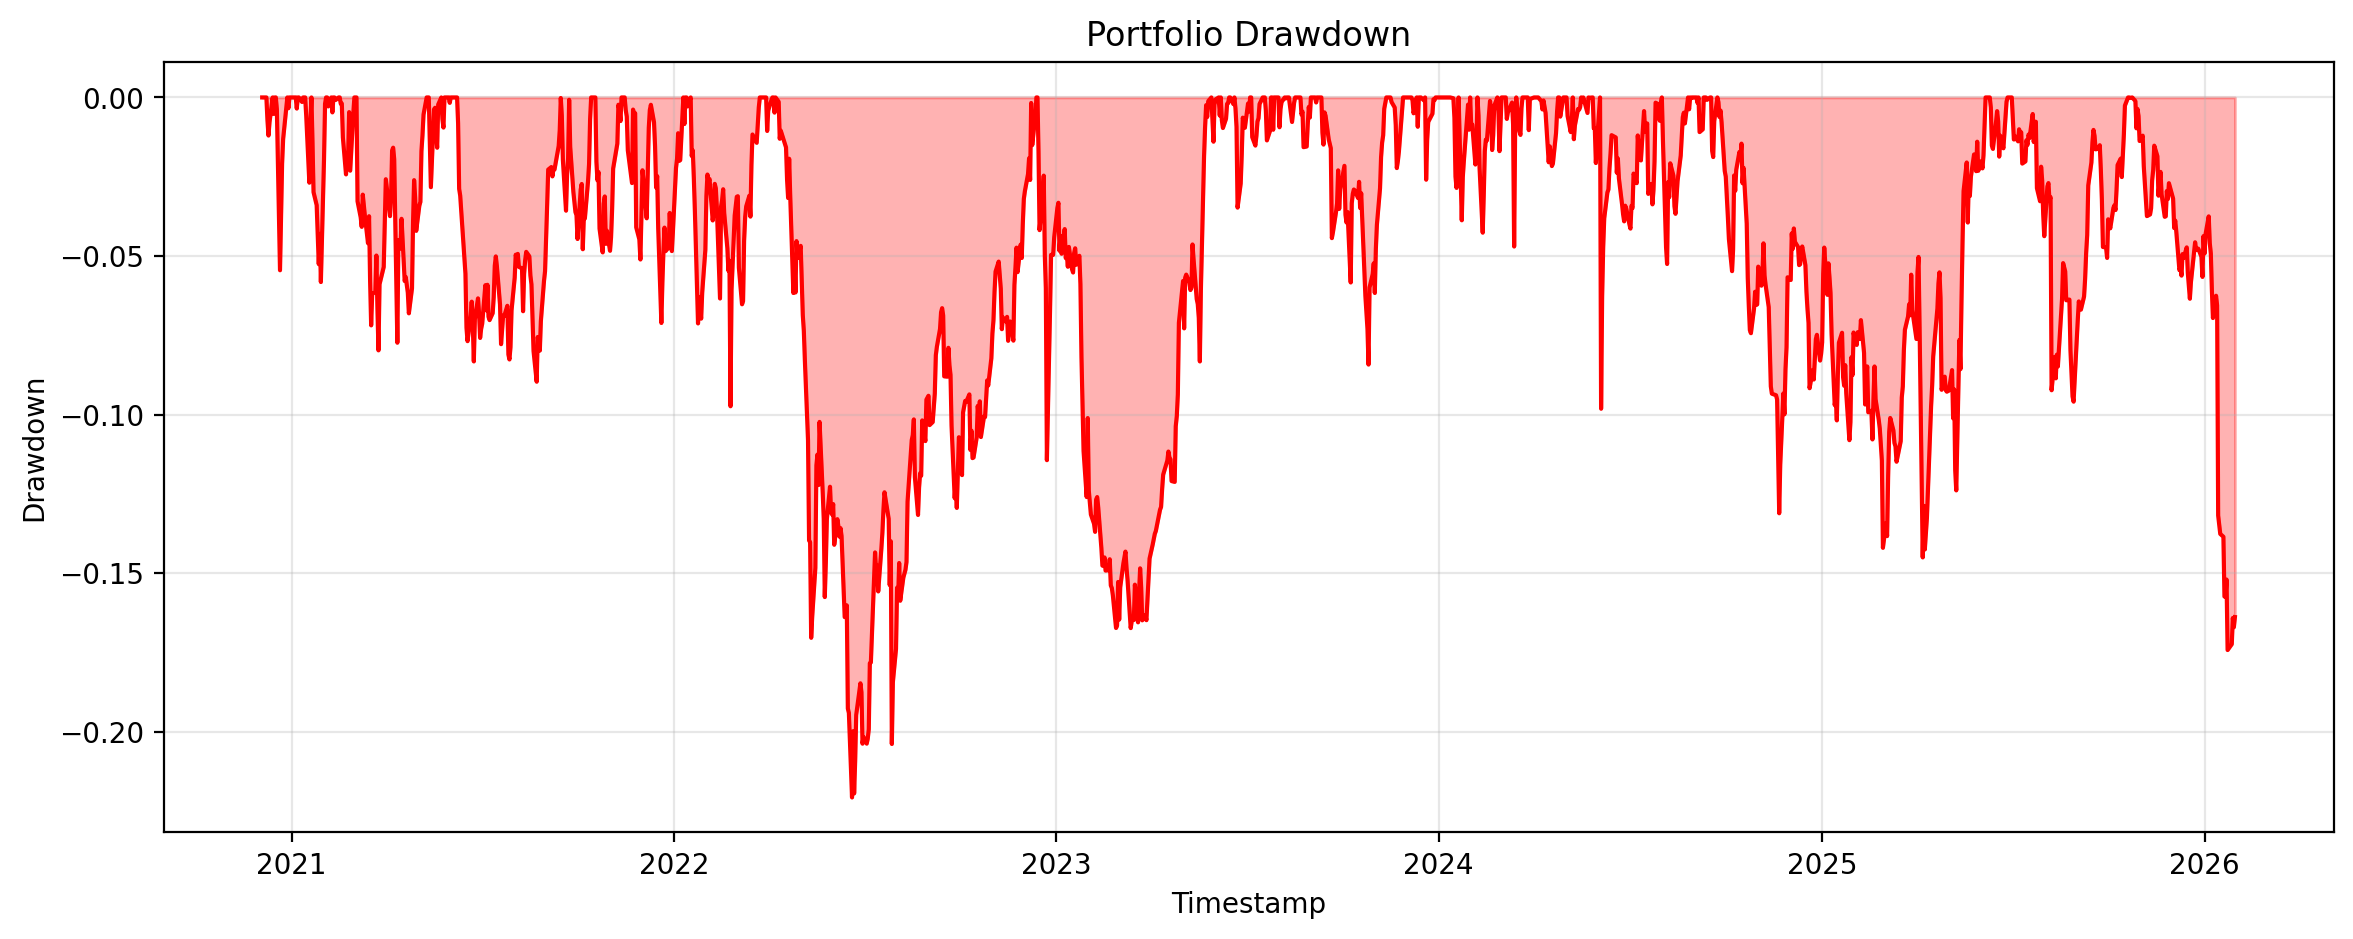

In [32]:
# -----------------------------------------
# DRAWDOWN
# -----------------------------------------

portfolio_df["drawdown"] = drawdown

plt.figure(figsize=(14,5), dpi=200)

plt.plot(portfolio_df["date"], portfolio_df["drawdown"], color="red")
plt.fill_between(portfolio_df["date"], portfolio_df["drawdown"], 0, color="red", alpha=0.3)

plt.title("Portfolio Drawdown")
plt.xlabel("Timestamp")
plt.ylabel("Drawdown")
plt.grid(alpha=0.3)

plt.show()

**Interpretation:** The value of 0.15 means risk of downside is at 15%

In [33]:
# -----------------------------------------
# HIT RATIO
# -----------------------------------------

In [34]:
# daily hit ratio

hit_ratio_daily = (returns > 0).mean()
print(f"Daily Hit Ratio: {hit_ratio_daily:.2%}")

Daily Hit Ratio: 56.22%


In [35]:
# rebalance level - hit ratio

rebalance_returns = []

for i in range(len(rebalance_dates) - 1):

    start = rebalance_dates[i]
    end = rebalance_dates[i + 1]

    period = portfolio_df[
        (portfolio_df["date"] > start) &
        (portfolio_df["date"] <= end)
    ]

    total_return = (1 + period["return"]).prod() - 1

    rebalance_returns.append(total_return)

rebalance_returns = np.array(rebalance_returns)

hit_ratio_rebalance = (rebalance_returns > 0).mean()

print(f"Rebalance Hit Ratio: {hit_ratio_rebalance:.2%}")

Rebalance Hit Ratio: 63.33%


## Portfolio Performance Summary

### Return Metrics
- **CAGR:** 24.28%  
  - Indicates strong absolute returns, significantly outperforming typical market benchmarks.

---

### Risk Metrics
- **Volatility:** 20.98%  
  - Slightly elevated, reflecting an active, high-return strategy.

- **Max Drawdown:** -22.07%  
  - Represents moderate downside risk; within acceptable limits for alpha strategies.

---

### Risk-Adjusted Performance
- **Sharpe Ratio:** 1.16  
  - Demonstrates solid risk-adjusted returns (return per unit risk).

- **Sortino Ratio:** 1.41  
  - Higher than Sharpe, indicating better control over downside volatility.

---

### Consistency Metrics
- **Daily Hit Ratio:** 56.22%  
  - Shows a modest but consistent predictive edge over random chance.

- **Rebalance Hit Ratio:** 63.33%  
  - Strong indicator of consistent performance across holding periods.

---

## Overall Interpretation
The strategy delivers strong absolute returns (~24% CAGR) with a Sharpe ratio of 1.16, indicating decent risk-adjusted performance. The higher Sortino ratio suggests that downside risk is relatively well controlled. While the maximum drawdown of ~22% indicates moderate risk exposure, the rebalance hit ratio of ~63% highlights consistent performance across investment cycles. Overall, the model demonstrates a stable alpha signal, with scope for further improvement in risk control and Sharpe optimization.